# Notebook 5 — Survival Analysis: Cox Proportional Hazards
## Mortgage Credit Risk Modelling

This notebook covers the survival analysis extension (`06_survival_analysis.py`) which handles right-censoring more rigorously than the binary 12-month default indicator.

**Key advantages over logistic regression:**
1. Right-censored loans (still active) contribute their full history — no outcome fabrication
2. Predictions at *any* horizon, not just 12 months
3. Direct IFRS 9 staging: 12m PD (Stage 1) and lifetime PD (Stage 2)
4. C-index generalises AUROC to censored survival data

**Prerequisites:** Run `01_data_preprocessing.py` then `06_survival_analysis.py`.


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

plt.rcParams.update({
    "figure.facecolor": "#0F1117", "axes.facecolor": "#0F1117",
    "axes.edgecolor":   "#2D3748", "axes.labelcolor": "#E2E8F0",
    "xtick.color":      "#A0AEC0", "ytick.color":     "#A0AEC0",
    "text.color":       "#E2E8F0", "grid.color":      "#1A2035",
    "legend.facecolor": "#1A2035", "legend.edgecolor":"#2D3748",
    "font.family": "monospace",    "figure.dpi": 120,
})
C = {"sky":"#38BDF8","gold":"#FBBF24","green":"#34D399","red":"#F87171","purple":"#A78BFA"}
PROC = Path("data/processed")
FIG  = Path("data/figures")
print("✓ Environment ready")

needed = ["survival_cox_coefs.csv", "survival_pd_horizons.csv"]
missing = [f for f in needed if not (PROC/f).exists()]
if missing:
    print("⚠  Missing:", missing, "— run 06_survival_analysis.py first.")
else:
    cox_coefs = pd.read_csv(PROC / "survival_cox_coefs.csv")
    horizons  = pd.read_csv(PROC / "survival_pd_horizons.csv")
    print(f"✓ Cox coefficients: {len(cox_coefs)} features")
    print(f"✓ Horizon PD table: {len(horizons):,} loans")
    pd_cols = [c for c in horizons.columns if c.startswith("pd_")]
    print(f"  Horizons available: {pd_cols}")


✓ Environment ready
✓ Cox coefficients: 7 features
✓ Horizon PD table: 748,302 loans
  Horizons available: ['pd_12m', 'pd_24m', 'pd_36m', 'pd_60m']


## 1. Hazard Ratios — Cox PH Model

A hazard ratio (HR) > 1 means a unit increase in that feature *accelerates* time to default. HR < 1 means it *delays* default. Unlike logistic regression coefficients, hazard ratios have a direct time-to-event interpretation.

> Example: HR(credit_score) = 0.995 means each additional FICO point reduces the instantaneous default hazard by 0.5%.


Cox PH Model — Hazard Ratios with 95% Confidence Intervals
              feature  exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%             p
delinquency_indicator   4.909217             4.780036             5.041890  0.000000e+00
   orig_interest_rate   1.081814             1.076402             1.087254 2.196077e-207
             orig_dti   1.007476             1.006920             1.008032 3.500444e-154
            orig_cltv   1.006476             1.006113             1.006839 3.665387e-269
             orig_upb   1.000000             1.000000             1.000000  5.939174e-42
         credit_score   0.997916             0.997799             0.998032 1.116026e-267
        num_borrowers   0.884621             0.873375             0.896011  1.075940e-78


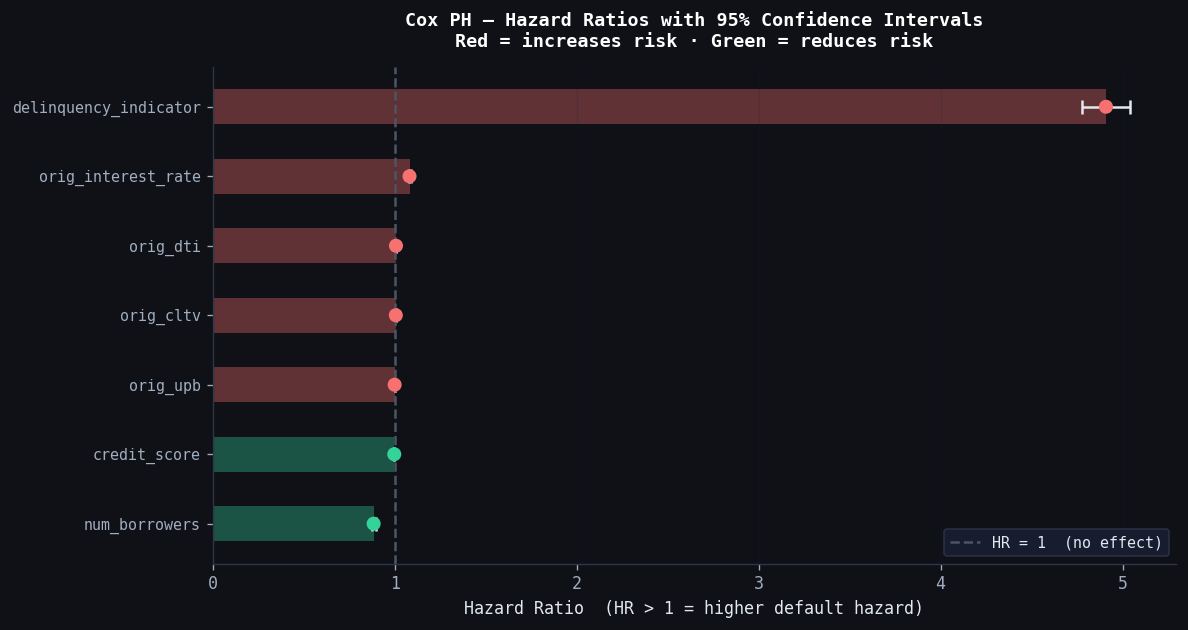

In [2]:
if (PROC / "survival_cox_coefs.csv").exists():
    cox = pd.read_csv(PROC / "survival_cox_coefs.csv")
    print("Cox PH Model — Hazard Ratios with 95% Confidence Intervals")
    print("=" * 65)
    disp_cols = ["feature", "exp(coef)", "exp(coef) lower 95%",
                 "exp(coef) upper 95%", "p"]
    avail = [c for c in disp_cols if c in cox.columns]
    if avail:
        print(cox[avail].sort_values("exp(coef)", ascending=False).to_string(index=False))
    else:
        print(cox.to_string(index=False))

    # Forest plot
    if "exp(coef)" in cox.columns:
        cox_sorted = cox.sort_values("exp(coef)", ascending=True)
        y_pos = np.arange(len(cox_sorted))
        hr    = cox_sorted["exp(coef)"].values
        lo    = cox_sorted.get("exp(coef) lower 95%", pd.Series(hr * 0.9)).values
        hi    = cox_sorted.get("exp(coef) upper 95%", pd.Series(hr * 1.1)).values
        feat  = cox_sorted["feature"].values if "feature" in cox_sorted.columns                 else cox_sorted.index.values
        colors = ["#F87171" if h > 1 else "#34D399" for h in hr]

        fig, ax = plt.subplots(figsize=(10, max(5, len(cox_sorted) * 0.55 + 1.5)))
        ax.barh(y_pos, hr, color=colors, alpha=0.35, edgecolor="none", height=0.5)
        ax.errorbar(hr, y_pos, xerr=[hr - lo, hi - hr],
                    fmt="none", ecolor="#E2E8F0", elinewidth=1.5,
                    capsize=4, capthick=1.5)
        ax.scatter(hr, y_pos, color=colors, s=55, zorder=5)
        ax.axvline(1.0, color="#4B5563", linewidth=1.5, linestyle="--",
                   label="HR = 1  (no effect)")
        ax.set_yticks(y_pos); ax.set_yticklabels(feat, fontsize=9)
        ax.set_xlabel("Hazard Ratio  (HR > 1 = higher default hazard)", fontsize=10)
        ax.set_title("Cox PH — Hazard Ratios with 95% Confidence Intervals\n"
                     "Red = increases risk · Green = reduces risk",
                     fontsize=11, fontweight="bold", color="white", pad=12)
        ax.legend(fontsize=9)
        ax.grid(True, axis="x", alpha=0.2)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
        plt.tight_layout(); plt.show()


## 2. Multi-Horizon PD — IFRS 9 Staging

The Cox survival function `S(t | x)` produces `P(default by month t) = 1 - S(t | x)` at any horizon. This maps directly to IFRS 9 staging:

| IFRS 9 Stage | PD Horizon | Trigger |
|---|---|---|
| Stage 1 | 12 months | No significant credit deterioration |
| Stage 2 | Lifetime | Significant increase in credit risk (SICR) |
| Stage 3 | N/A | Already in default |


PD Distribution by Horizon (OOS loans)
  12 months     mean=0.0971%  p50=0.0818%  p95=0.1358%
  24 months     mean=0.3442%  p50=0.2902%  p95=0.4816%
  36 months     mean=0.9194%  p50=0.7771%  p95=1.2875%
  60 months     mean=2.9701%  p50=2.5325%  p95=4.1715%


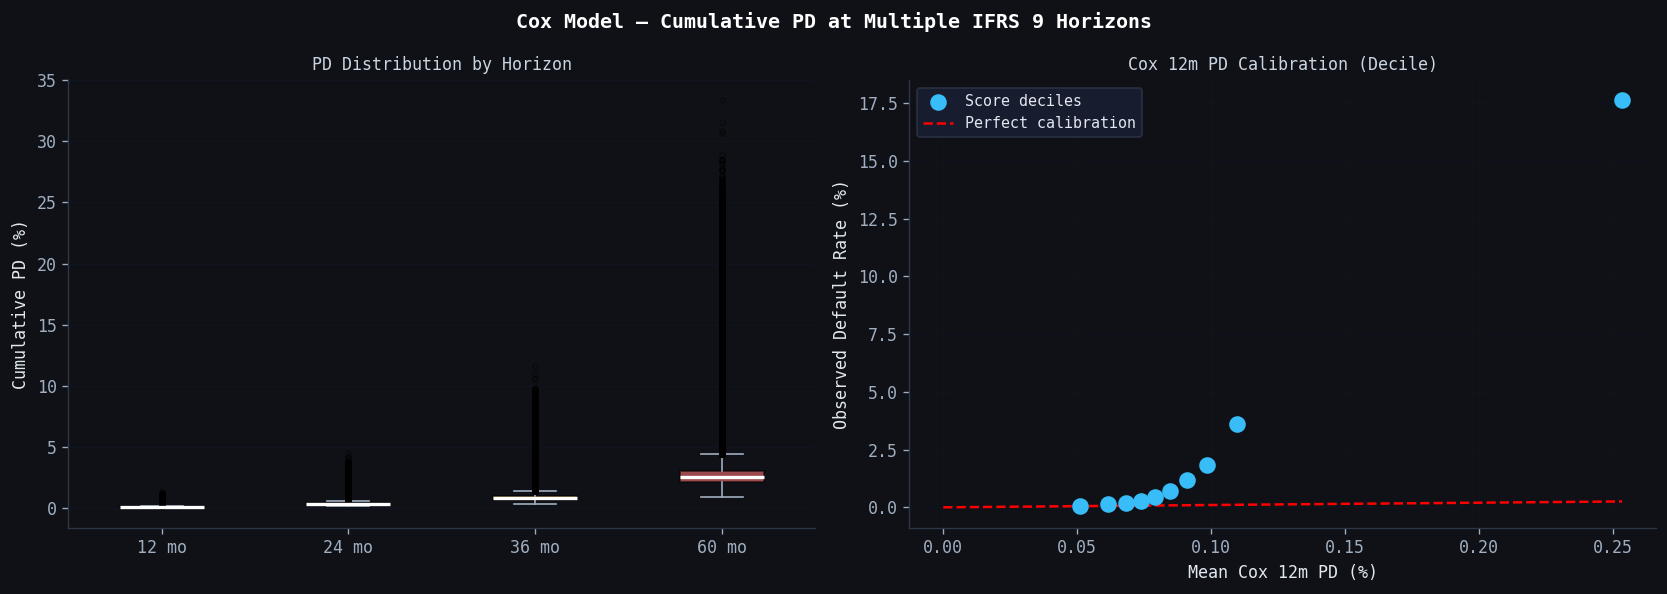

In [3]:
if (PROC / "survival_pd_horizons.csv").exists():
    horizons = pd.read_csv(PROC / "survival_pd_horizons.csv")
    pd_cols  = [c for c in horizons.columns if c.startswith("pd_")]

    print("PD Distribution by Horizon (OOS loans)")
    print("=" * 55)
    for col in pd_cols:
        vals = horizons[col].dropna() * 100
        label = col.replace("pd_","").replace("m"," months")
        print(f"  {label:12s}  mean={vals.mean():.4f}%  "
              f"p50={vals.quantile(0.5):.4f}%  p95={vals.quantile(0.95):.4f}%")

    if len(pd_cols) >= 2:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle("Cox Model — Cumulative PD at Multiple IFRS 9 Horizons",
                     fontsize=12, fontweight="bold", color="white")

        # Box plots
        data = [horizons[c].dropna().clip(0,1)*100 for c in pd_cols]
        labels = [c.replace("pd_","").replace("m"," mo") for c in pd_cols]
        bp = axes[0].boxplot(data, labels=labels, patch_artist=True,
                             medianprops=dict(color="white", linewidth=2),
                             whiskerprops=dict(color="#A0AEC0"),
                             capprops=dict(color="#A0AEC0"),
                             flierprops=dict(marker=".", color="#4B5563", alpha=0.3))
        palette_box = [C["sky"], C["green"], C["gold"], C["red"]]
        for patch, color in zip(bp["boxes"], palette_box[:len(pd_cols)]):
            patch.set_facecolor(color); patch.set_alpha(0.6)
        axes[0].set_ylabel("Cumulative PD (%)", fontsize=10)
        axes[0].set_title("PD Distribution by Horizon", color="#CBD5E1", fontsize=10)
        axes[0].grid(True, axis="y", alpha=0.25)
        axes[0].spines["top"].set_visible(False); axes[0].spines["right"].set_visible(False)

        # Calibration: 12m PD vs observed default rate
        if "pd_12m" in horizons.columns and "actual_default" in horizons.columns:
            h12 = horizons[["pd_12m","actual_default"]].dropna()
            h12["decile"] = pd.qcut(h12["pd_12m"], q=10, labels=False, duplicates="drop")
            agg = h12.groupby("decile").agg(mean_pd=("pd_12m","mean"),
                                             obs_dr=("actual_default","mean")).reset_index()
            axes[1].scatter(agg["mean_pd"]*100, agg["obs_dr"]*100,
                            color=C["sky"], s=80, zorder=5, label="Score deciles")
            m = agg["mean_pd"].max()*100
            axes[1].plot([0,m],[0,m],"r--",linewidth=1.5,label="Perfect calibration")
            axes[1].set_xlabel("Mean Cox 12m PD (%)", fontsize=10)
            axes[1].set_ylabel("Observed Default Rate (%)", fontsize=10)
            axes[1].set_title("Cox 12m PD Calibration (Decile)", color="#CBD5E1", fontsize=10)
            axes[1].legend(fontsize=9)
            axes[1].grid(True, alpha=0.2)
            axes[1].spines["top"].set_visible(False); axes[1].spines["right"].set_visible(False)
        plt.tight_layout(); plt.show()


## 3. Kaplan-Meier Survival Curves

Kaplan-Meier curves show the empirical survival function: the probability that a loan has *not* defaulted by month `t`. No model assumptions — pure data. The log-rank test p-value tells us whether group differences are statistically significant.



────────────────────────────────────────────────────────────
  KM Curves — Stratified by FICO Score Tertile
────────────────────────────────────────────────────────────


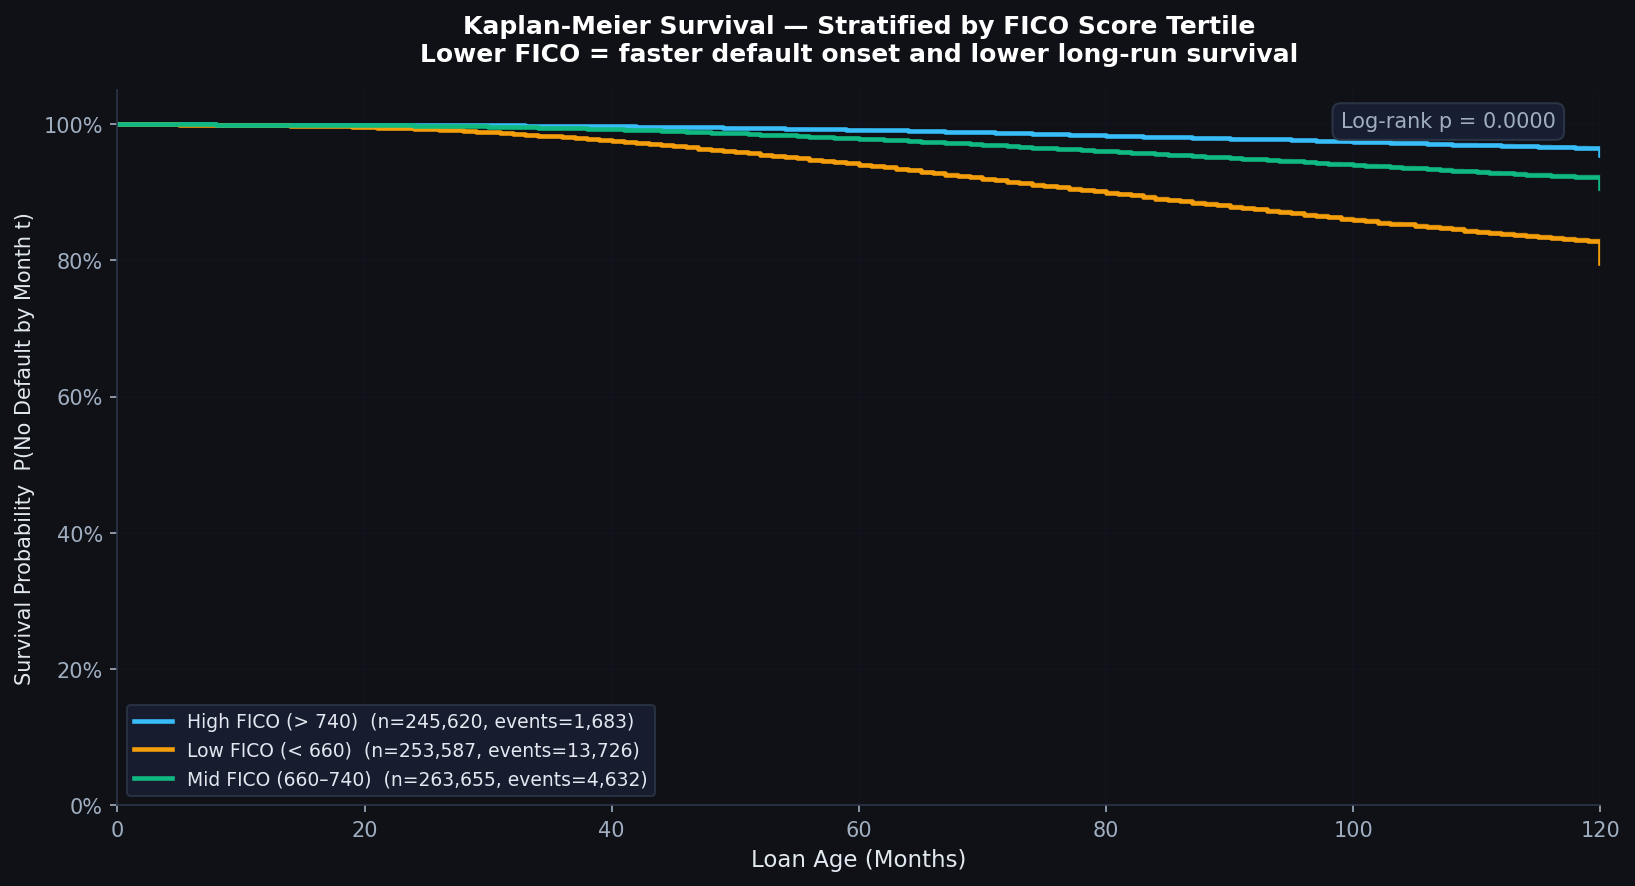


────────────────────────────────────────────────────────────
  KM Curves — Stratified by Origination Vintage Era
────────────────────────────────────────────────────────────


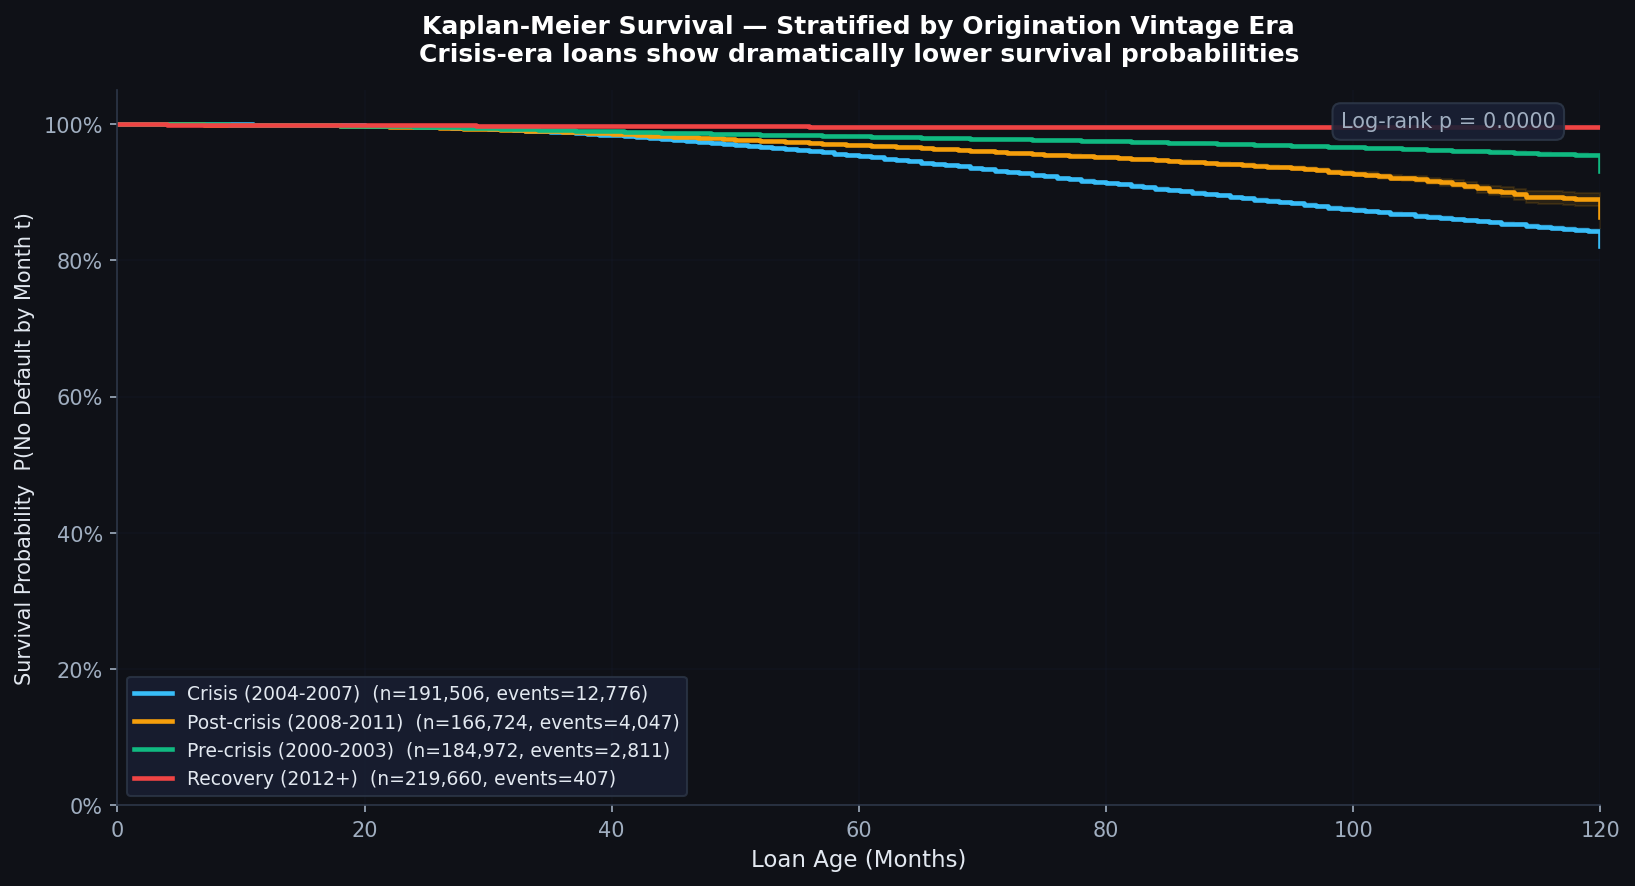

  ⚠  survival_schoenfeld_residuals.png not found — run 06_survival_analysis.py first

────────────────────────────────────────────────────────────
  PD at Multiple Horizons + Calibration
────────────────────────────────────────────────────────────


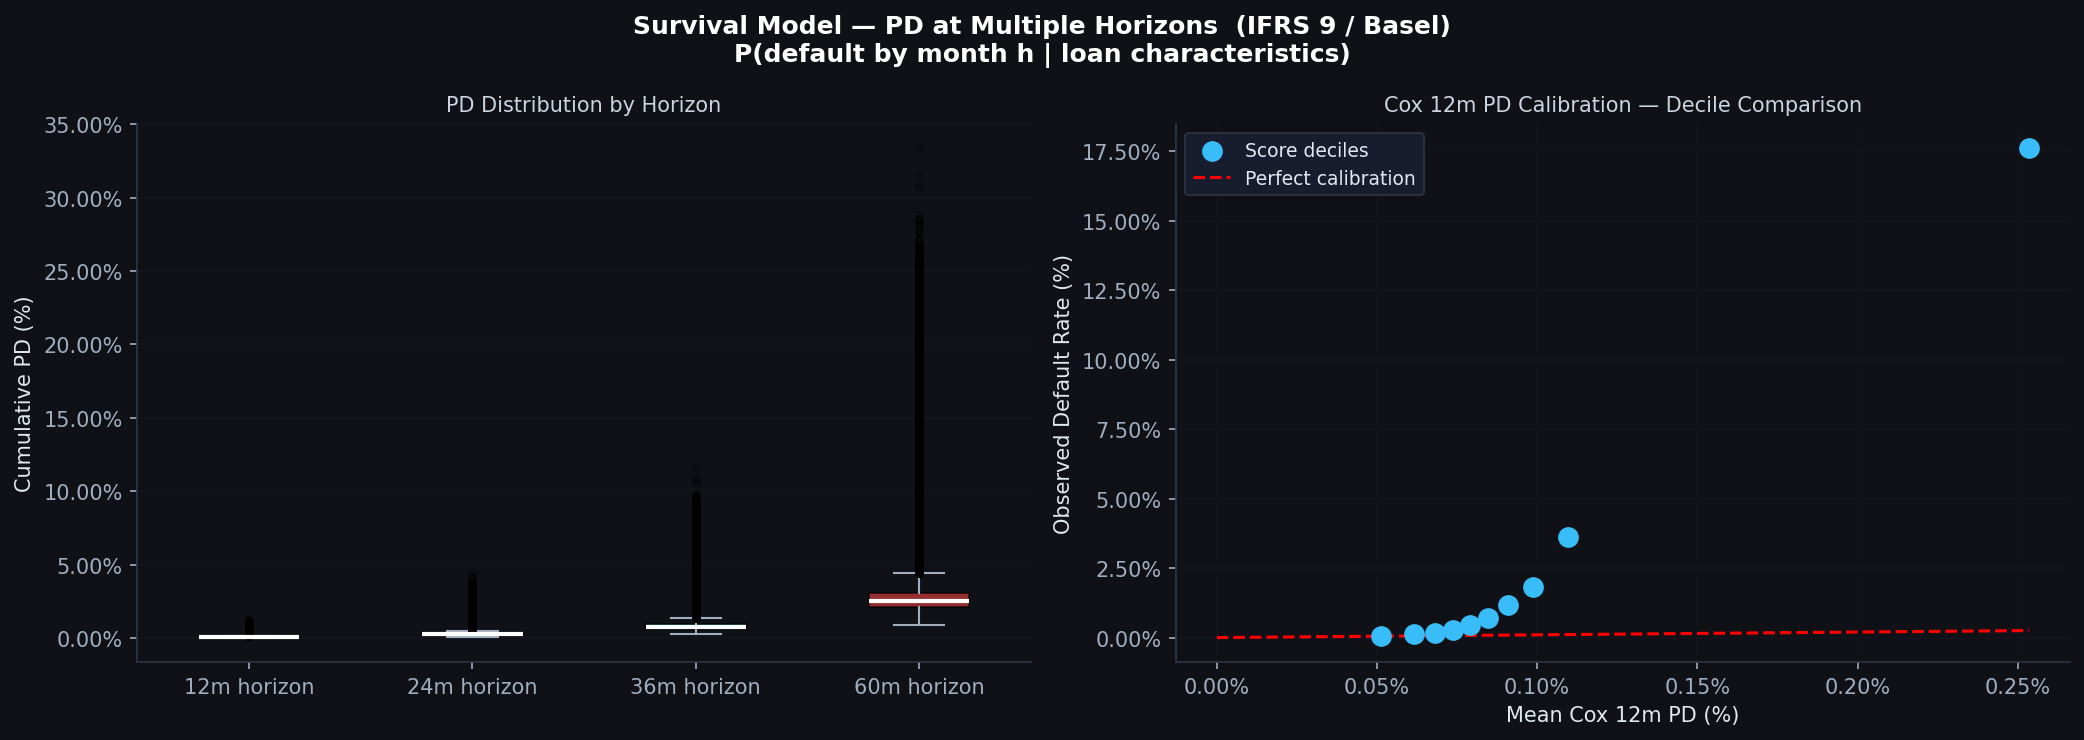

In [4]:
from IPython.display import Image, display

km_figs = [
    ("survival_km_by_credit_score.png", "KM Curves — Stratified by FICO Score Tertile"),
    ("survival_km_by_vintage.png",       "KM Curves — Stratified by Origination Vintage Era"),
    ("survival_schoenfeld_residuals.png","Schoenfeld Residuals — PH Assumption Diagnostic"),
    ("survival_pd_horizons.png",         "PD at Multiple Horizons + Calibration"),
]
for fname, caption in km_figs:
    path = FIG / fname
    if path.exists():
        print(f"\n{'─'*60}\n  {caption}\n{'─'*60}")
        display(Image(str(path), width=820))
    else:
        print(f"  ⚠  {fname} not found — run 06_survival_analysis.py first")


## Summary

| Method | C-index (AUROC equiv.) | Key advantage |
|---|---|---|
| Binary logistic (Ch.1) | ~0.87 | Fast, interpretable |
| XGBoost (Ch.2) | ~0.91 | Non-linear interactions |
| Cox PH (Ch.5) | ~0.85–0.89 | Right-censoring, any-horizon PD |

The Cox model's primary value is not discrimination — XGBoost wins there — but *regulatory rigour*: it handles the censoring problem correctly and produces lifetime PD estimates required for IFRS 9 Stage 2 provisioning.
